# 2431342 Swoyam Pokharel - Part III NLP Task

## Hate Speech / Offensive Language / Neither Classification

This notebook trains the NLP models for the tweet classification task. The main choices are preprocessing, class imbalance handling, recurrent architecture, and pretrained embeddings.


## 1. Setup

Fixed seed, TensorFlow runtime setup, project paths, imports, and output folders.


In [1]:
import sys
from pathlib import Path

# Keep imports working from either the notebooks folder or the project root.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.runtime import setup_runtime

SEED = 42
setup_runtime(SEED)

import json
import pandas as pd
import tensorflow as tf

from src.paths import NLP, ensure_dirs
from src.nlp.data import TARGET_NAMES, class_weights, label_distribution, load_dataset, split_dataset
from src.nlp.eda import show_label_distribution, show_text_length_distribution, show_top_words, top_words
from src.nlp.embeddings import build_embedding_matrix, load_embedding
from src.nlp.experiments import NlpExperiment, comparison, registry, run_many
from src.nlp.models import (
    build_bilstm,
    build_lstm,
    build_pretrained_small_regularized_lstm,
    build_simple_rnn,
    build_small_regularized_lstm,
)
from src.nlp.text import LemmaNormalizer, StemNormalizer, add_clean_text, encode_texts, make_tokenizer, percentile_max_len
from src.plots import plot_metric_comparison

for path in [
    NLP.processed,
    NLP.figures / "eda",
    NLP.figures / "training_curves",
    NLP.figures / "confusion_matrices",
    NLP.figures / "comparisons",
    NLP.tables,
    NLP.histories,
    NLP.models,
    NLP.summaries,
    NLP.predictions,
]:
    ensure_dirs(path)

stem_normalizer = StemNormalizer()
lemma_normalizer = LemmaNormalizer()

pd.set_option("display.max_columns", 200)
# Store runtime details because TensorFlow and GPU versions affect trained results.
metadata = {
    "seed": SEED,
    "tensorflow_version": tf.__version__,
    "available_gpus": [device.name for device in tf.config.list_physical_devices("GPU")],
}
(NLP.tables / "environment_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
metadata


{'seed': 42,
 'tensorflow_version': '2.21.0',
 'available_gpus': ['/physical_device:GPU:0']}

## 2. Dataset Loading And Label Cleaning

The raw tweet file is loaded and mapped into the three required labels.


In [2]:
raw_df = load_dataset(NLP.data)
raw_df.to_csv(NLP.processed / "raw_with_clean_labels.csv", index=False)

summary = pd.DataFrame({
    "metric": ["rows", "classes"],
    "value": [len(raw_df), raw_df["label_clean"].nunique()],
})
summary.to_csv(NLP.tables / "dataset_summary.csv", index=False)
label_distribution(raw_df).to_csv(NLP.tables / "label_distribution.csv", index=False)
summary


,metric,value
0,rows,24783
1,classes,3


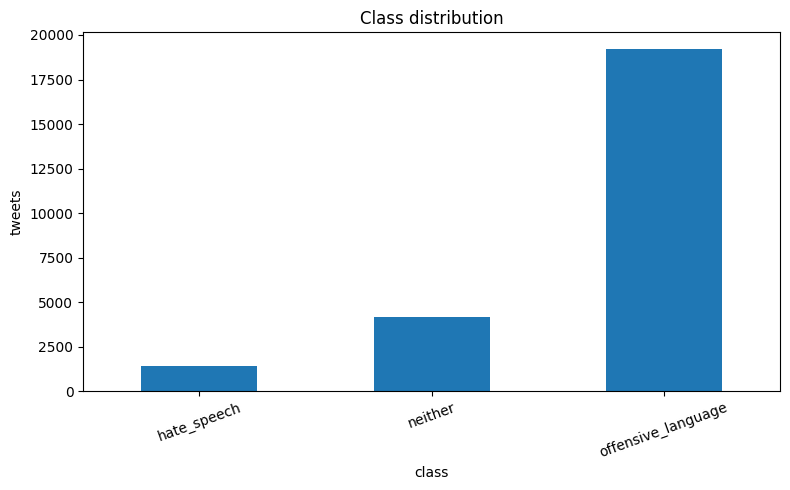

,label,count
0,offensive_language,19190
1,neither,4163
2,hate_speech,1430


In [3]:
show_label_distribution(raw_df, NLP.figures / "eda" / "label_distribution.png")
label_distribution(raw_df)


**Takeaway**

The dataset is heavily skewed toward `offensive_language`. `hate_speech` is the smallest class, so accuracy alone is not a reliable model selection metric.


## 3. Text Cleaning Variants

Two cleaned versions are created from the same tweets:

- **Stemmed:** Porter stemming cuts words down more aggressively.
- **Lemmatized:** WordNet keeps more readable word forms.

Both remove URLs, mentions, hashtag markers, numbers, special characters, stopwords, and Twitter `rt` noise.


In [4]:
stemmed_df = add_clean_text(raw_df, normalizer=stem_normalizer)
lemmatized_df = add_clean_text(raw_df, normalizer=lemma_normalizer)

stemmed_df.to_csv(NLP.processed / "cleaned_stemmed_dataset.csv", index=False)
lemmatized_df.to_csv(NLP.processed / "cleaned_lemmatized_dataset.csv", index=False)

examples = pd.DataFrame({
    "raw_text": raw_df["text"].head(8),
    "stemmed_text": stemmed_df["clean_text"].head(8),
    "lemmatized_text": lemmatized_df["clean_text"].head(8),
    "label": raw_df["label_clean"].head(8),
})
examples.to_csv(NLP.tables / "preprocessing_examples.csv", index=False)
examples


,raw_text,stemmed_text,lemmatized_text,label
0,!!! RT @mayasolovely: As a woman you shouldn't...,woman complain clean hous man trash,woman complain cleaning house man trash,neither
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,boy dat cold tyga dwn bad cuffin dat hoe st place,boy dat cold tyga dwn bad cuffin dat hoe st place,offensive_language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,dawg fuck bitch start confus shit,dawg fuck bitch start confused shit,offensive_language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,look like tranni,look like tranny,offensive_language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,shit hear true faker bitch told ya,shit hear true faker bitch told ya,offensive_language
5,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just...",shit just blow claim faith somebodi fuck hoe,shit just blow claim faithful somebody fucking...,offensive_language
6,"!!!!!!""@__BrighterDays: I can not just sit up ...",just sit hate bitch got shit go,just sit hate bitch got shit going,offensive_language
7,!!!!&#8220;@selfiequeenbri: cause I'm tired of...,caus tire big bitch come skinni girl,cause tired big bitch coming skinny girl,offensive_language


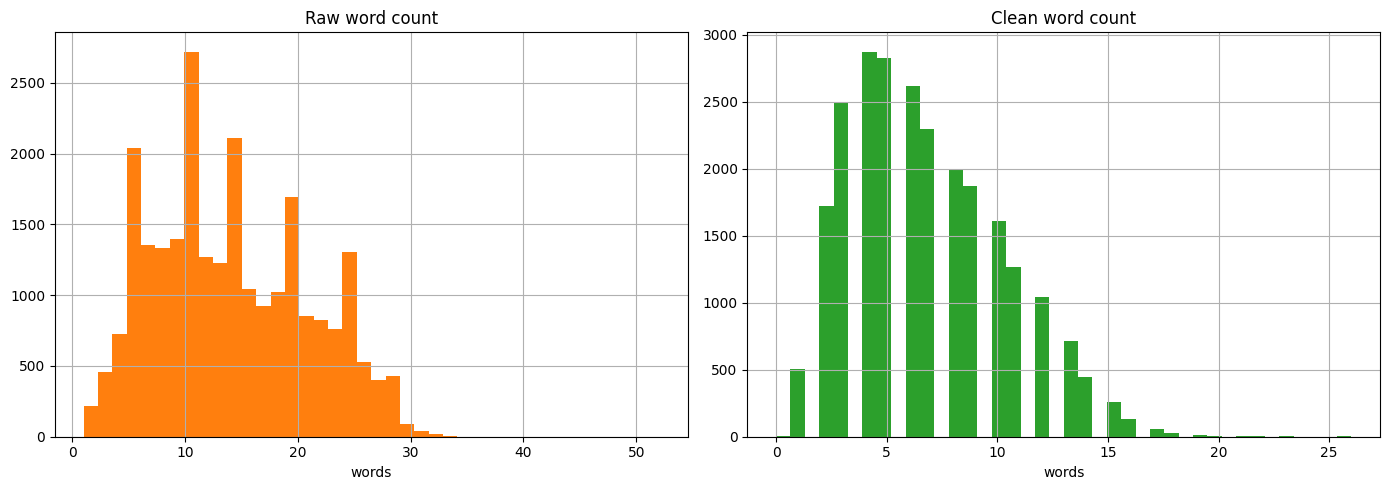

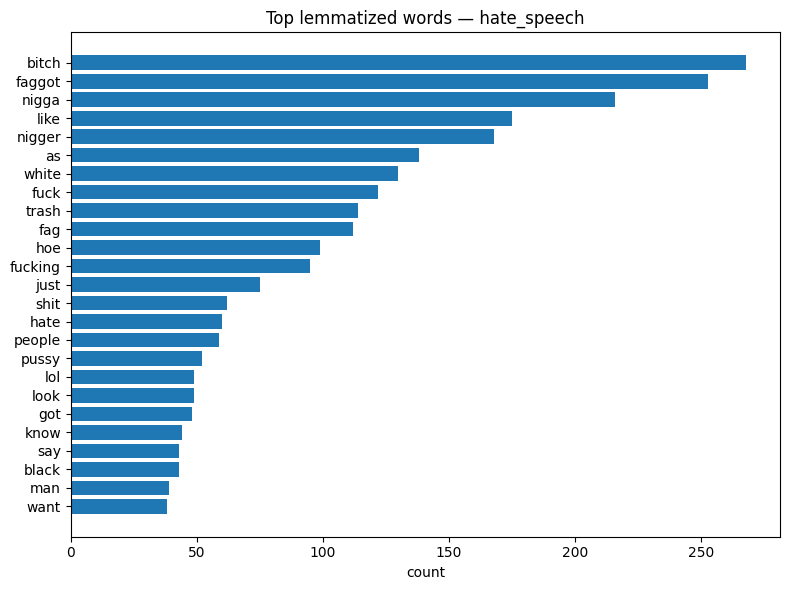

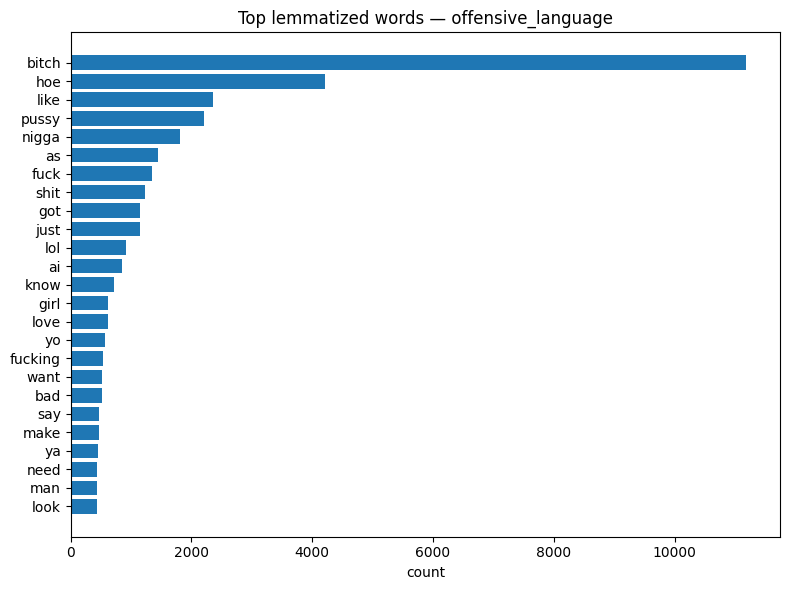

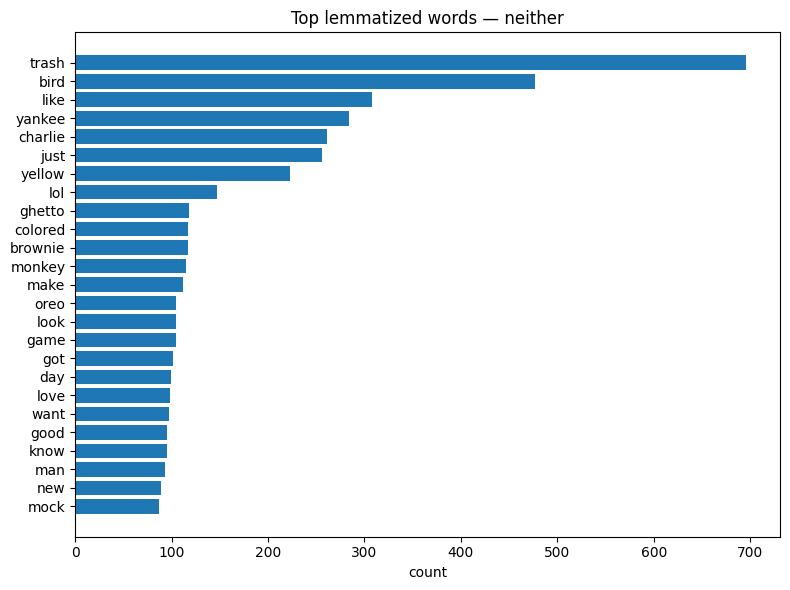

In [5]:
show_text_length_distribution(lemmatized_df, NLP.figures / "eda" / "text_length_distribution_lemmatized.png")

for label in TARGET_NAMES:
    words = top_words(lemmatized_df, label=label, n=25)
    words.to_csv(NLP.tables / f"top_words_lemmatized_{label}.csv", index=False)
    show_top_words(words, f"Top lemmatized words — {label}", NLP.figures / "eda" / f"top_words_lemmatized_{label}.png")


## 4. Tokenization And Padding

Stemming and lemmatization produce different vocabularies, so each variant gets its own tokenizer. Padding uses the 95th percentile length rather than letting a few long tweets set the whole sequence size.


In [6]:
VOCAB_SIZE = 20_000
OOV_TOKEN = "<OOV>"

def prepare_variant(df, name):
    train_df, test_df = split_dataset(df, seed=SEED)
    tokenizer = make_tokenizer(train_df["clean_text"], vocab_size=VOCAB_SIZE, oov_token=OOV_TOKEN)
    # Use the 95th percentile so a few long tweets do not increase every padded sequence.
    max_len = percentile_max_len(train_df["clean_word_count"], percentile=95)
    x_train = encode_texts(tokenizer, train_df["clean_text"], max_len)
    x_test = encode_texts(tokenizer, test_df["clean_text"], max_len)

    train_df.to_csv(NLP.processed / f"split_train_{name}.csv", index=False)
    test_df.to_csv(NLP.processed / f"split_test_{name}.csv", index=False)
    (NLP.processed / f"tokenizer_{name}.json").write_text(tokenizer.to_json(), encoding="utf-8")

    return {
        "name": name,
        "train_df": train_df,
        "test_df": test_df,
        "tokenizer": tokenizer,
        "max_len": max_len,
        "x_train": x_train,
        "x_test": x_test,
        "y_train": train_df["label_id"],
        "y_test": test_df["label_id"],
        # Keep class weights tied to the split because imbalance changes with the training data.
        "class_weight": class_weights(train_df["label_id"]),
    }

stemmed = prepare_variant(stemmed_df, "stemmed")
lemmatized = prepare_variant(lemmatized_df, "lemmatized")

config = pd.DataFrame([
    {"variant": "stemmed", "max_len": stemmed["max_len"], "vocab_seen": len(stemmed["tokenizer"].word_index)},
    {"variant": "lemmatized", "max_len": lemmatized["max_len"], "vocab_seen": len(lemmatized["tokenizer"].word_index)},
])
config.to_csv(NLP.tables / "preprocessing_config.csv", index=False)
config


,variant,max_len,vocab_seen
0,stemmed,13,13675
1,lemmatized,13,15945


**Takeaway**

Both variants end up with `max_len = 13`. Lemmatization keeps a larger vocabulary, which is expected because it does less aggressive word reduction than stemming.


## 5. Simple RNN Experiment Grid

This is the baseline grid:

1. Simple RNN + stemming
2. Simple RNN + stemming + class weights
3. Simple RNN + lemmatization
4. Simple RNN + lemmatization + class weights

The goal is to decide which preprocessing and imbalance setup is worth carrying into the LSTM runs.


Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8492 - loss: 0.4605 - val_accuracy: 0.8949 - val_loss: 0.3272
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9129 - loss: 0.2798 - val_accuracy: 0.8913 - val_loss: 0.3328
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9403 - loss: 0.1908 - val_accuracy: 0.8752 - val_loss: 0.4087
Epoch 4/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9588 - loss: 0.1329 - val_accuracy: 0.8475 - val_loss: 0.4781


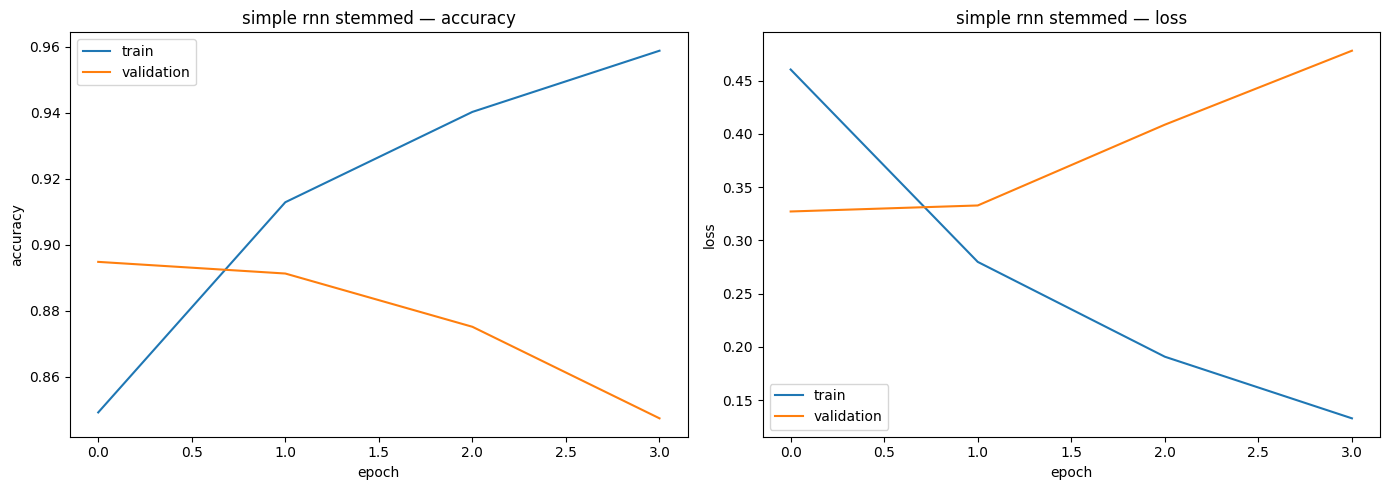

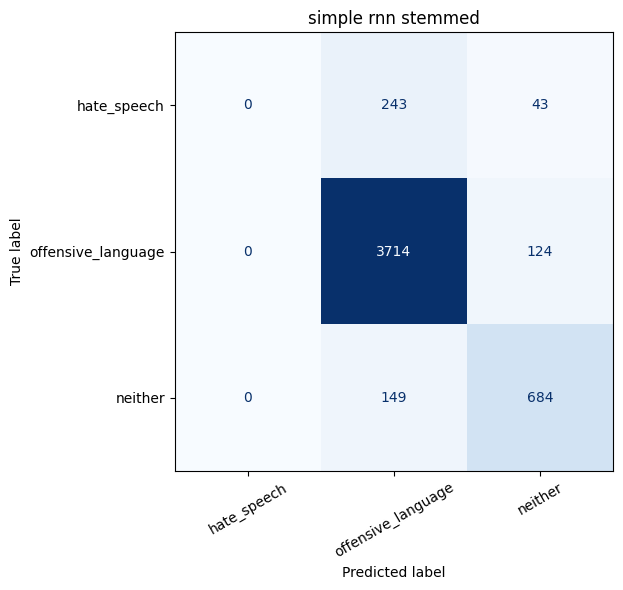

Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6547 - loss: 0.8538 - val_accuracy: 0.8132 - val_loss: 0.5542
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7877 - loss: 0.5210 - val_accuracy: 0.7867 - val_loss: 0.5595
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8619 - loss: 0.3246 - val_accuracy: 0.7257 - val_loss: 0.6890
Epoch 4/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9090 - loss: 0.2162 - val_accuracy: 0.7650 - val_loss: 0.7234


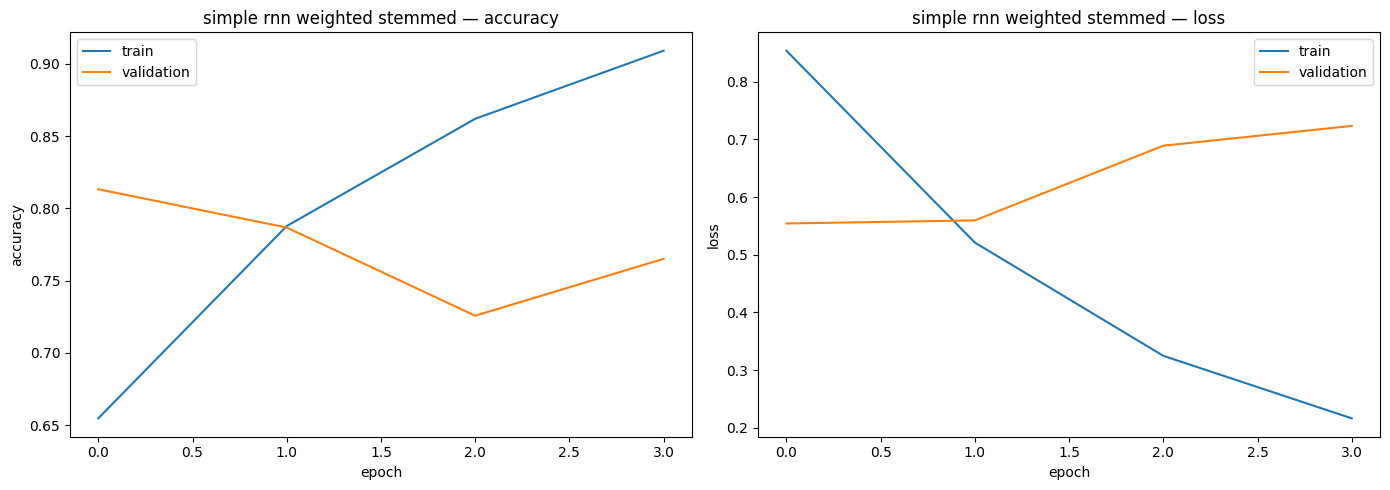

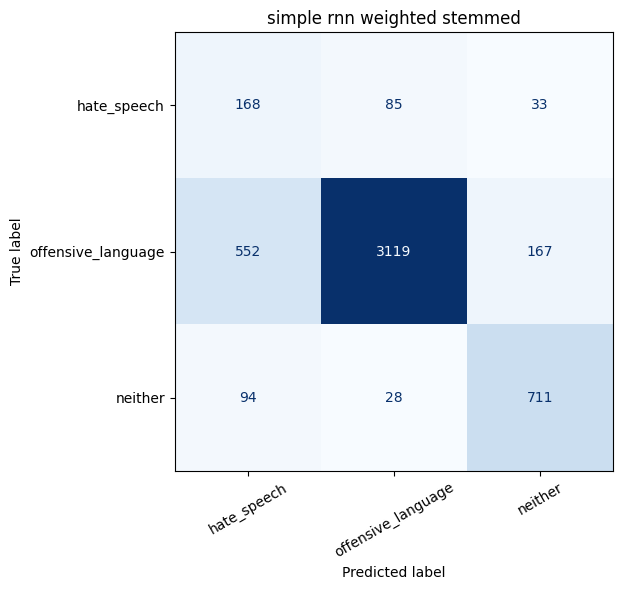

Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8495 - loss: 0.4466 - val_accuracy: 0.8944 - val_loss: 0.2919
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9145 - loss: 0.2593 - val_accuracy: 0.8936 - val_loss: 0.3093
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9410 - loss: 0.1752 - val_accuracy: 0.8855 - val_loss: 0.4064
Epoch 4/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9596 - loss: 0.1305 - val_accuracy: 0.8409 - val_loss: 0.4860


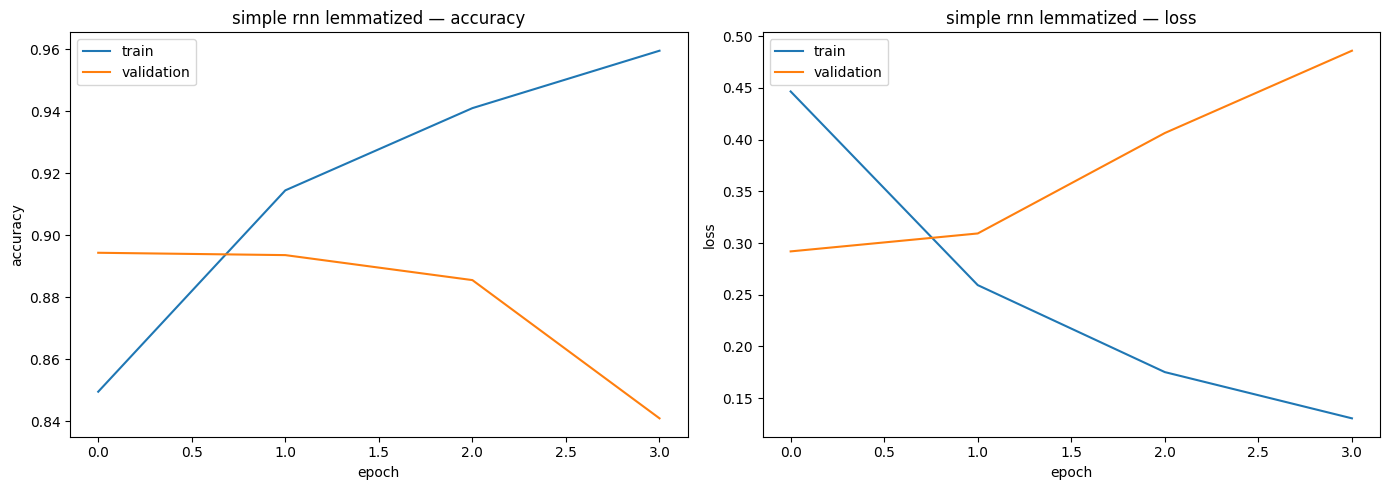

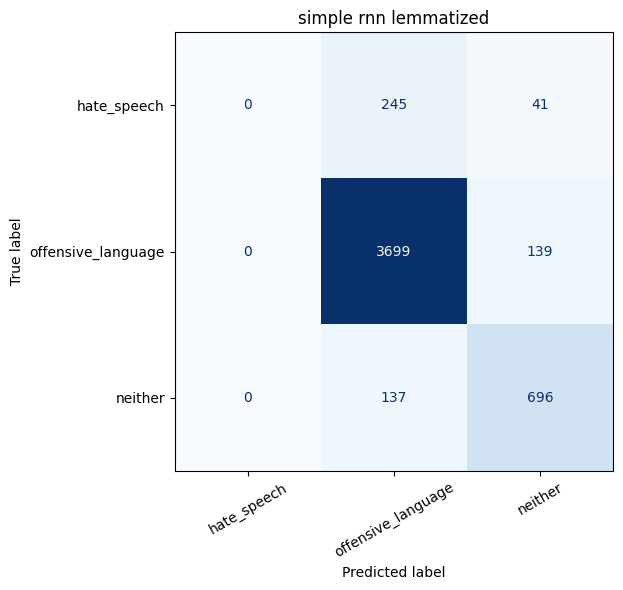

Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6437 - loss: 0.8547 - val_accuracy: 0.8212 - val_loss: 0.5474
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8259 - loss: 0.4798 - val_accuracy: 0.7635 - val_loss: 0.6730
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8916 - loss: 0.2940 - val_accuracy: 0.7945 - val_loss: 0.6042
Epoch 4/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9231 - loss: 0.1988 - val_accuracy: 0.7837 - val_loss: 0.7146


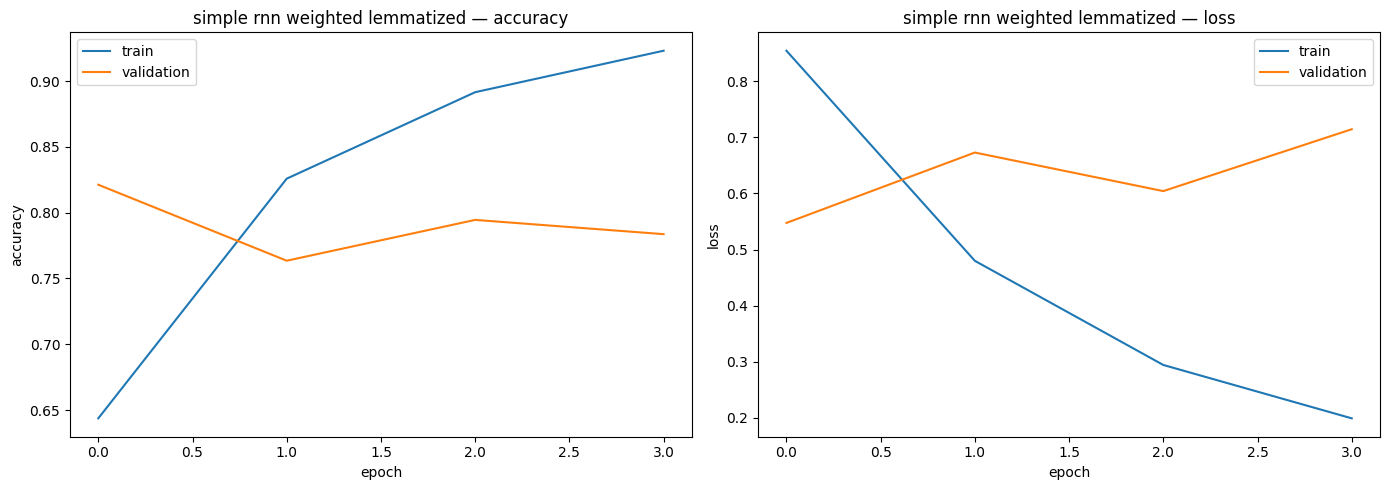

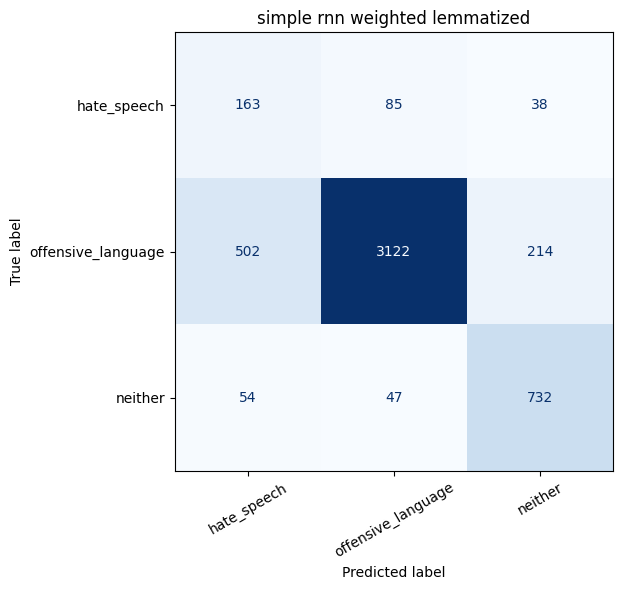

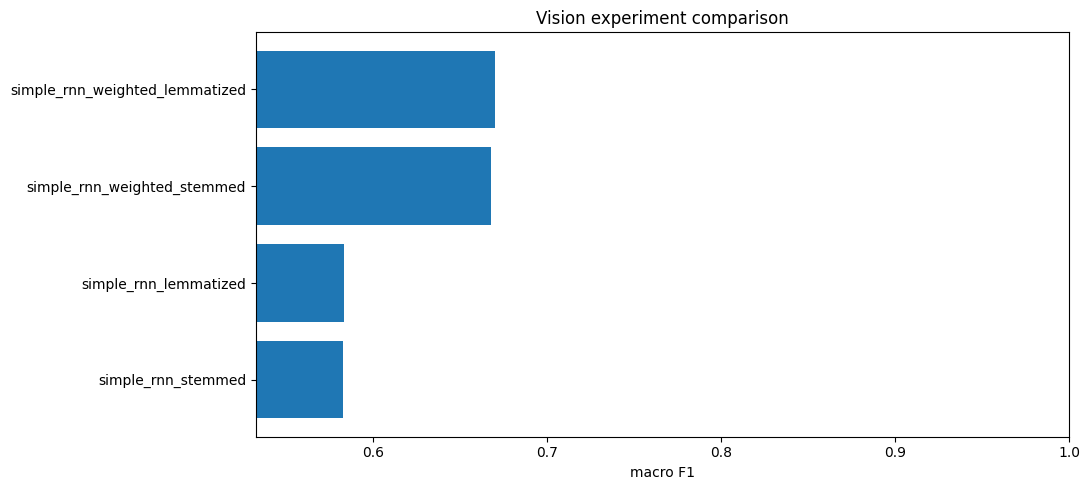

,experiment_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,misclassified_samples,epochs_trained,training_time_seconds,trainable_parameters,non_trainable_parameters
0,simple_rnn_weighted_lemmatized,0.810369,0.643347,0.754042,0.670177,0.835793,940,4,25.193455,2574531,0
1,simple_rnn_weighted_stemmed,0.806536,0.650629,0.751206,0.667714,0.837786,959,4,25.672314,2574531,0
2,simple_rnn_lemmatized,0.886625,0.566972,0.599772,0.582907,0.860194,562,4,24.060275,2574531,0
3,simple_rnn_stemmed,0.887230,0.569430,0.596273,0.582466,0.860479,559,4,27.617948,2574531,0


In [7]:
nlp_results = {}

simple_rnn_runs = [
    (
        stemmed,
        NlpExperiment(
            name="simple_rnn_stemmed",
            build_model=lambda: build_simple_rnn(VOCAB_SIZE, len(TARGET_NAMES)),
            class_weight=None,
        ),
    ),
    (
        stemmed,
        NlpExperiment(
            name="simple_rnn_weighted_stemmed",
            build_model=lambda: build_simple_rnn(VOCAB_SIZE, len(TARGET_NAMES)),
            class_weight=stemmed["class_weight"],
        ),
    ),
    (
        lemmatized,
        NlpExperiment(
            name="simple_rnn_lemmatized",
            build_model=lambda: build_simple_rnn(VOCAB_SIZE, len(TARGET_NAMES)),
            class_weight=None,
        ),
    ),
    (
        lemmatized,
        NlpExperiment(
            name="simple_rnn_weighted_lemmatized",
            build_model=lambda: build_simple_rnn(VOCAB_SIZE, len(TARGET_NAMES)),
            class_weight=lemmatized["class_weight"],
        ),
    ),
]

for prepared, experiment in simple_rnn_runs:
    nlp_results.update(run_many(
        [experiment],
        prepared["x_train"],
        prepared["y_train"],
        prepared["x_test"],
        prepared["y_test"],
        prepared["test_df"],
        NLP,
    ))

simple_rnn_table = comparison(
    nlp_results,
    [experiment.name for _, experiment in simple_rnn_runs],
    NLP.tables / "simple_rnn_comparison.csv",
)
plot_metric_comparison(simple_rnn_table, NLP.figures / "comparisons" / "simple_rnn_macro_f1_comparison.png")
simple_rnn_table


**Takeaway**

The weighted lemmatized Simple RNN has the best macro F1 in this grid. The unweighted models have higher accuracy, but they do worse on minority-class balance.


## 6. Simple RNN Verdict

Models are ranked by macro F1 first, then accuracy, then training time. Macro F1 matters here because the minority classes are easy to hide behind high overall accuracy.


In [8]:
simple_rnn_registry = registry(nlp_results, NLP.tables / "simple_rnn_registry.csv")
best_simple_rnn_name = simple_rnn_registry.iloc[0]["experiment_name"]
best_simple_rnn_name


'simple_rnn_weighted_lemmatized'

## 7. LSTM Experiments

The Simple RNN grid selected weighted lemmatized text. This section keeps that setup fixed and compares plain LSTM, dropout LSTM, and Bidirectional LSTM.


Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7281 - loss: 0.6872 - val_accuracy: 0.7900 - val_loss: 0.6149
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8544 - loss: 0.3907 - val_accuracy: 0.8122 - val_loss: 0.5242
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8935 - loss: 0.2536 - val_accuracy: 0.8064 - val_loss: 0.5456
Epoch 4/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9252 - loss: 0.1782 - val_accuracy: 0.8134 - val_loss: 0.5833
Epoch 5/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9424 - loss: 0.1312 - val_accuracy: 0.8386 - val_loss: 0.6397


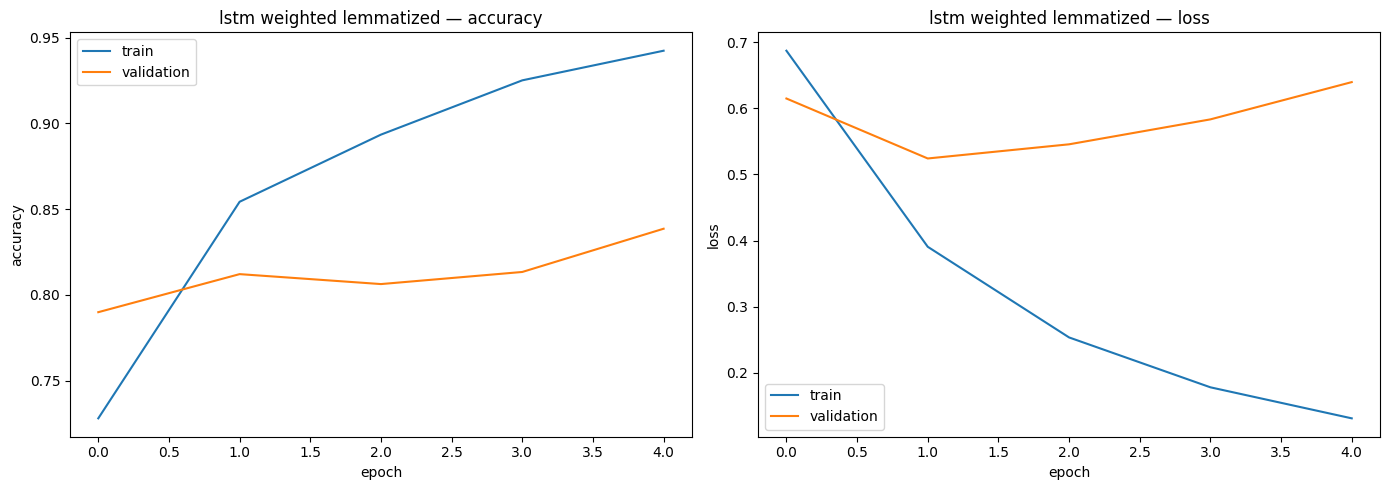

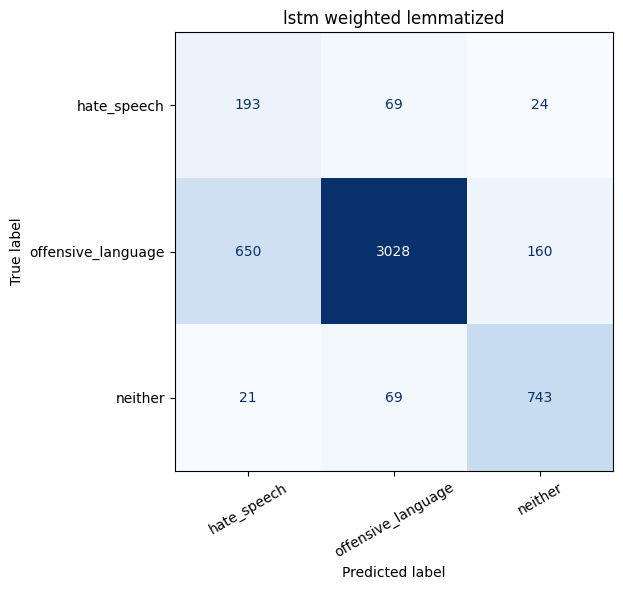

Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7241 - loss: 0.7865 - val_accuracy: 0.8248 - val_loss: 0.6007
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8448 - loss: 0.4664 - val_accuracy: 0.8313 - val_loss: 0.5448
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8778 - loss: 0.3118 - val_accuracy: 0.8253 - val_loss: 0.4829
Epoch 4/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9130 - loss: 0.2138 - val_accuracy: 0.8008 - val_loss: 0.6377
Epoch 5/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9295 - loss: 0.1693 - val_accuracy: 0.8235 - val_loss: 0.7152
Epoch 6/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9462 - loss: 0.1265 - val_accuracy: 0.8255 - val_loss: 0.7934


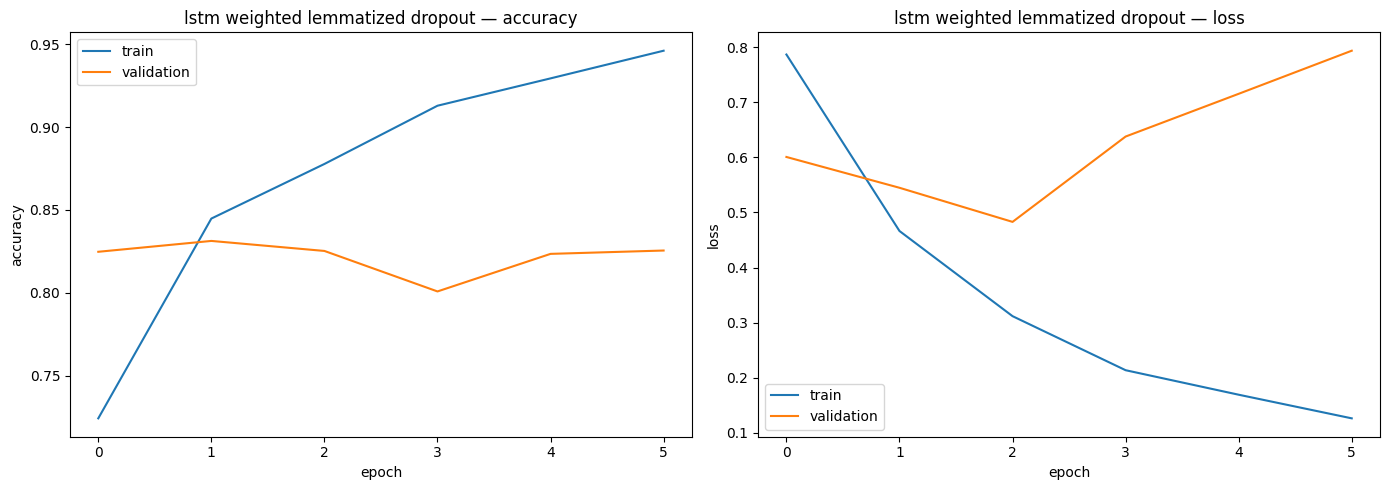

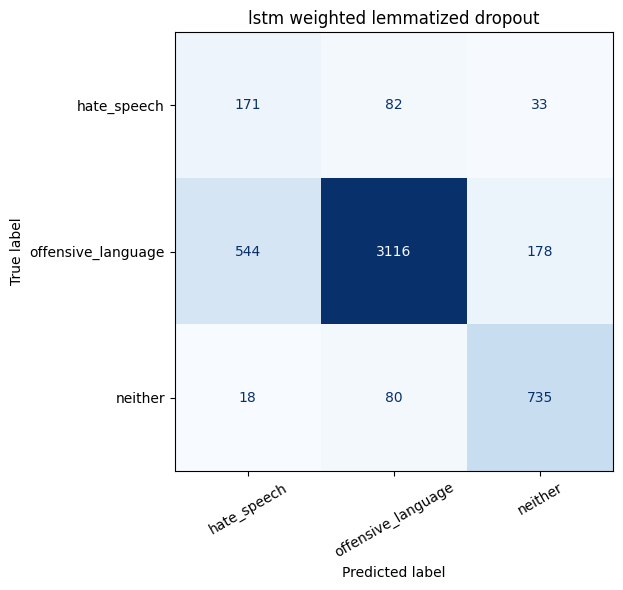

Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7651 - loss: 0.6545 - val_accuracy: 0.7650 - val_loss: 0.5911
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8516 - loss: 0.3498 - val_accuracy: 0.8172 - val_loss: 0.5102
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9028 - loss: 0.2160 - val_accuracy: 0.8185 - val_loss: 0.5188
Epoch 4/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9317 - loss: 0.1455 - val_accuracy: 0.8253 - val_loss: 0.5221
Epoch 5/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9508 - loss: 0.1022 - val_accuracy: 0.8434 - val_loss: 0.6396


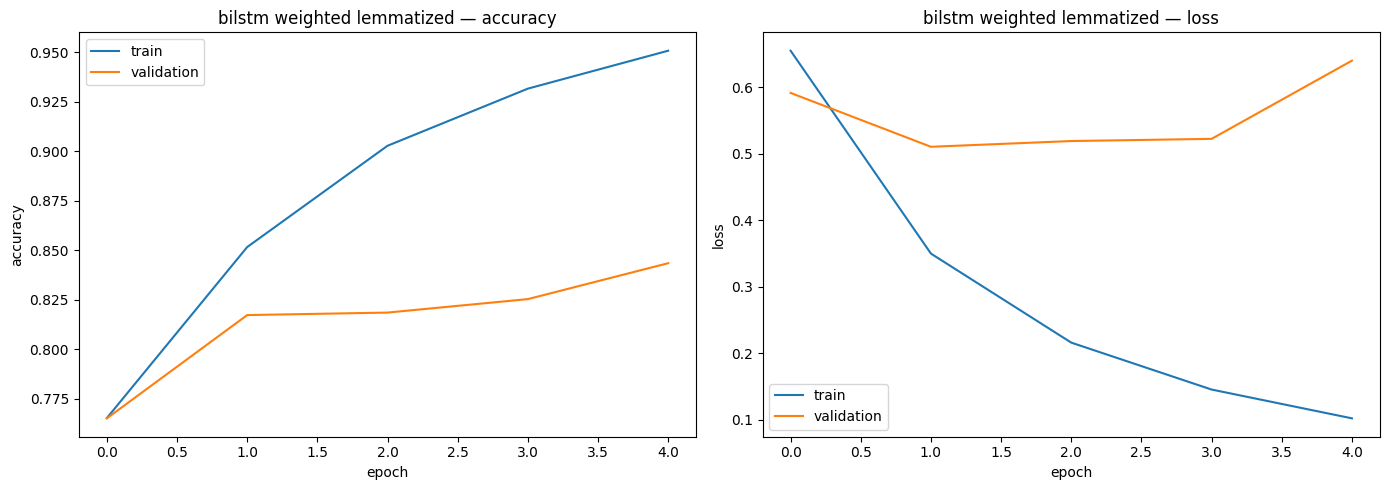

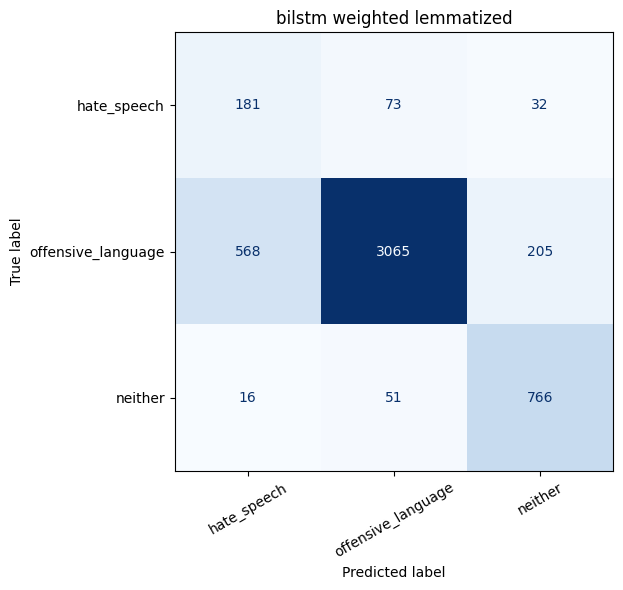

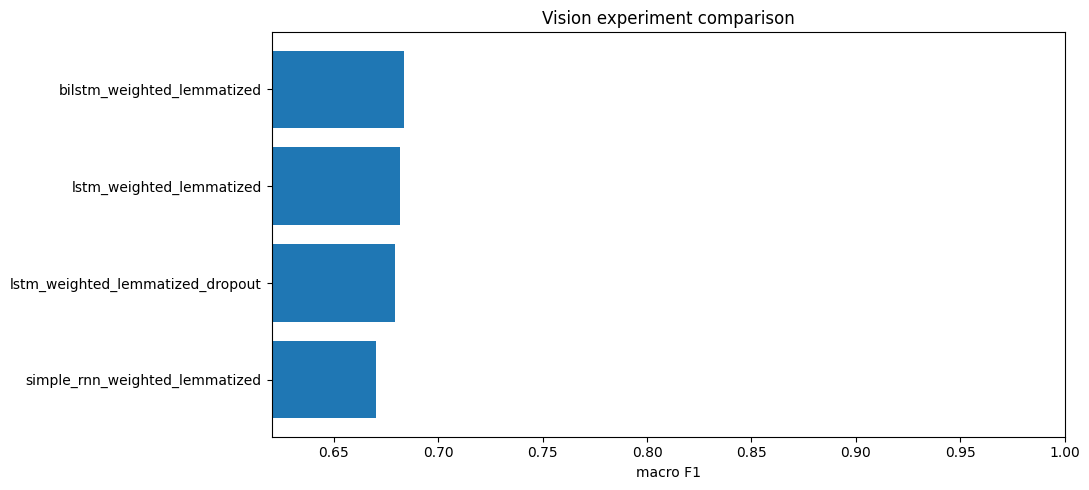

,experiment_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,misclassified_samples,epochs_trained,training_time_seconds,trainable_parameters,non_trainable_parameters
0,bilstm_weighted_lemmatized,0.809361,0.653809,0.783676,0.683735,0.835517,945,5,20.211881,2663043,0
1,lstm_weighted_lemmatized,0.799677,0.660434,0.785245,0.681540,0.830711,993,5,16.220682,2611587,0
2,lstm_weighted_lemmatized_dropout,0.811378,0.653608,0.764045,0.679234,0.836296,935,6,20.041328,2611587,0
3,simple_rnn_weighted_lemmatized,0.810369,0.643347,0.754042,0.670177,0.835793,940,4,25.193455,2574531,0


In [9]:
lstm_experiments = [
    NlpExperiment(
        name="lstm_weighted_lemmatized",
        build_model=lambda: build_lstm(VOCAB_SIZE, len(TARGET_NAMES), use_dropout=False),
        class_weight=lemmatized["class_weight"],
    ),
    NlpExperiment(
        name="lstm_weighted_lemmatized_dropout",
        build_model=lambda: build_lstm(VOCAB_SIZE, len(TARGET_NAMES), use_dropout=True),
        class_weight=lemmatized["class_weight"],
    ),
    NlpExperiment(
        name="bilstm_weighted_lemmatized",
        build_model=lambda: build_bilstm(VOCAB_SIZE, len(TARGET_NAMES), use_dropout=False),
        class_weight=lemmatized["class_weight"],
    ),
]

nlp_results.update(run_many(
    lstm_experiments,
    lemmatized["x_train"],
    lemmatized["y_train"],
    lemmatized["x_test"],
    lemmatized["y_test"],
    lemmatized["test_df"],
    NLP,
))

lstm_table = comparison(
    nlp_results,
    [
        "simple_rnn_weighted_lemmatized",
        "lstm_weighted_lemmatized",
        "lstm_weighted_lemmatized_dropout",
        "bilstm_weighted_lemmatized",
    ],
    NLP.tables / "lstm_comparison.csv",
)
plot_metric_comparison(lstm_table, NLP.figures / "comparisons" / "lstm_macro_f1_comparison.png")
lstm_table


**Takeaway**

Bidirectional LSTM gives the strongest macro F1 in this group, but the improvement over plain weighted LSTM is small. The useful part is the recurrent upgrade, not a massive architecture jump.


## 8. Regularized LSTM Follow-Up

The first LSTM runs overfit after the early epochs. This run cuts the model down and adds regularization so the recurrent model is not just memorizing the training split.


Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5795 - loss: 0.8626 - val_accuracy: 0.8185 - val_loss: 0.6130
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8243 - loss: 0.5516 - val_accuracy: 0.8457 - val_loss: 0.5106
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8420 - loss: 0.4288 - val_accuracy: 0.7874 - val_loss: 0.5273
Epoch 4/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8482 - loss: 0.3734 - val_accuracy: 0.8255 - val_loss: 0.4842
Epoch 5/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8765 - loss: 0.3099 - val_accuracy: 0.8265 - val_loss: 0.5354
Epoch 6/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8908 - loss: 0.2743 - val_accuracy: 0.8480 - val_loss: 0.4893
Epoch 7/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9018 - loss: 0.2310 - val_accuracy: 0.8399 - val_loss: 0.5000


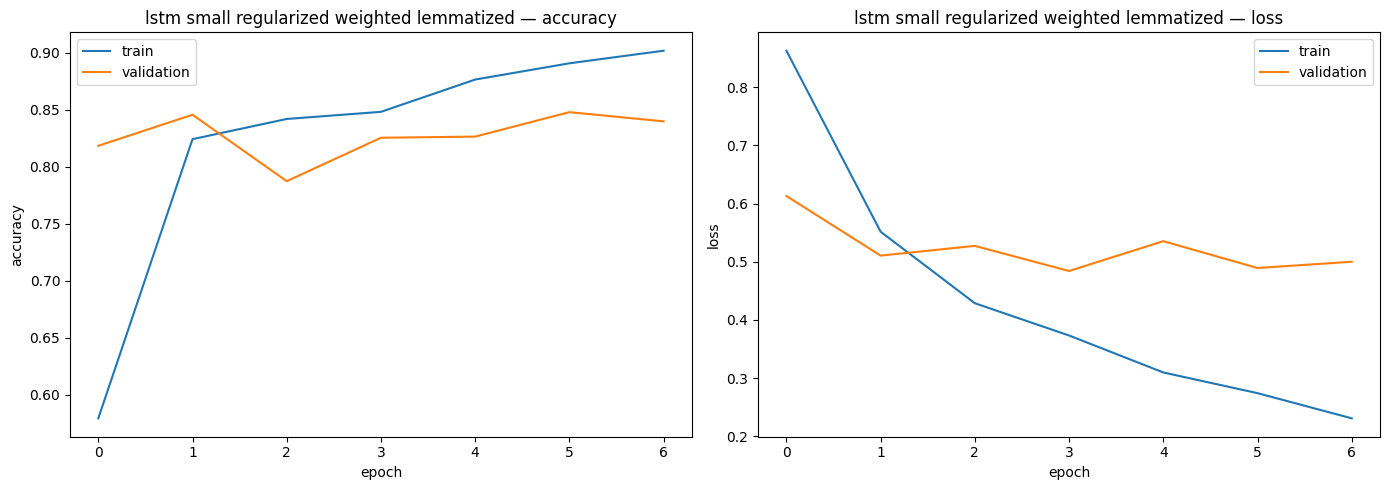

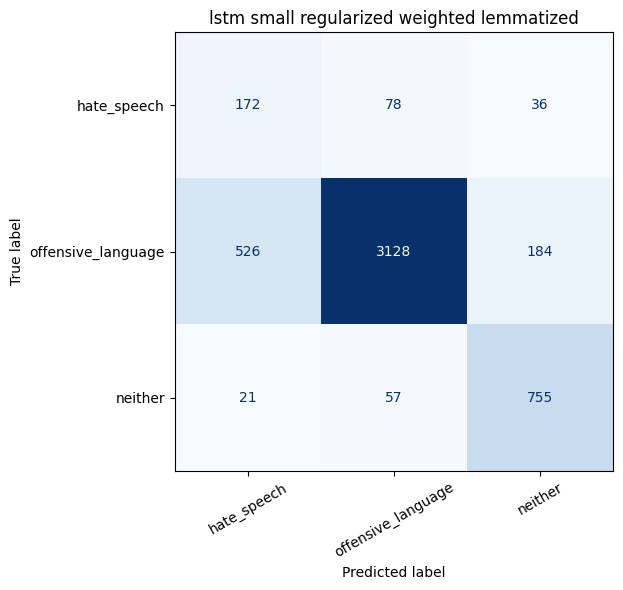

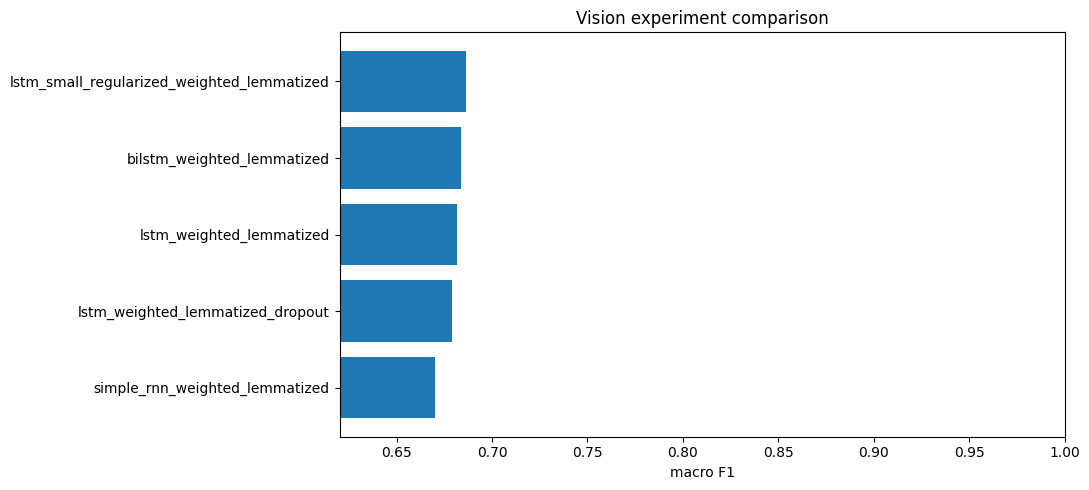

,experiment_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,misclassified_samples,epochs_trained,training_time_seconds,trainable_parameters,non_trainable_parameters
0,lstm_small_regularized_weighted_lemmatized,0.818035,0.657402,0.774256,0.686156,0.842220,902,7,86.142427,1292995,0
1,bilstm_weighted_lemmatized,0.809361,0.653809,0.783676,0.683735,0.835517,945,5,20.211881,2663043,0
2,lstm_weighted_lemmatized,0.799677,0.660434,0.785245,0.681540,0.830711,993,5,16.220682,2611587,0
3,lstm_weighted_lemmatized_dropout,0.811378,0.653608,0.764045,0.679234,0.836296,935,6,20.041328,2611587,0
4,simple_rnn_weighted_lemmatized,0.810369,0.643347,0.754042,0.670177,0.835793,940,4,25.193455,2574531,0


In [11]:
regularized_lstm = NlpExperiment(
    name="lstm_small_regularized_weighted_lemmatized",
    build_model=lambda: build_small_regularized_lstm(VOCAB_SIZE, len(TARGET_NAMES)),
    class_weight=lemmatized["class_weight"],
)

nlp_results.update(run_many(
    [regularized_lstm],
    lemmatized["x_train"],
    lemmatized["y_train"],
    lemmatized["x_test"],
    lemmatized["y_test"],
    lemmatized["test_df"],
    NLP,
))

lstm_table = comparison(
    nlp_results,
    [
        "simple_rnn_weighted_lemmatized",
        "lstm_weighted_lemmatized",
        "lstm_weighted_lemmatized_dropout",
        "bilstm_weighted_lemmatized",
        "lstm_small_regularized_weighted_lemmatized",
    ],
    NLP.tables / "lstm_comparison.csv",
)
plot_metric_comparison(lstm_table, NLP.figures / "comparisons" / "lstm_macro_f1_comparison.png")
lstm_table


**Takeaway**

The smaller regularized LSTM improves macro F1 and weighted F1 over the earlier LSTM runs. Cutting capacity helped more than adding a larger recurrent stack.


## 9. GloVe Embedding Experiments

The best trainable model is compared against two 50-dimensional pretrained embeddings:

1. `glove-wiki-gigaword-50`: general Wikipedia/news text.
2. `glove-twitter-50`: Twitter text.

This checks whether domain-specific word vectors help more than general text vectors.


,metric,value,embedding
0,found_words,12359.00,glove_wiki_50
1,missing_words,3586.00,glove_wiki_50
2,coverage_percent,77.51,glove_wiki_50


[=========================-------------------------] 50.8% 101.3/199.5MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[==================================================] 100.0% 199.5/199.5MB downloaded


,metric,value,embedding
0,found_words,14066.00,glove_twitter_50
1,missing_words,1879.00,glove_twitter_50
2,coverage_percent,88.22,glove_twitter_50


Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.4151 - loss: 0.9962 - val_accuracy: 0.8454 - val_loss: 0.5989
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.7117 - loss: 0.7510 - val_accuracy: 0.7988 - val_loss: 0.5866
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7636 - loss: 0.6626 - val_accuracy: 0.8285 - val_loss: 0.5059
Epoch 4/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7878 - loss: 0.6096 - val_accuracy: 0.8134 - val_loss: 0.4973
Epoch 5/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7994 - loss: 0.5538 - val_accuracy: 0.8109 - val_loss: 0.5107
Epoch 6/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8095 - loss: 0.5193 - val_accuracy: 0.8303 - val_loss: 0.4778
Epoch 7/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8221 - loss: 0.5079 - val_accuracy: 0.7927 - val_loss: 0.5476
Epoch 8/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8166 - loss: 0.4879 - 

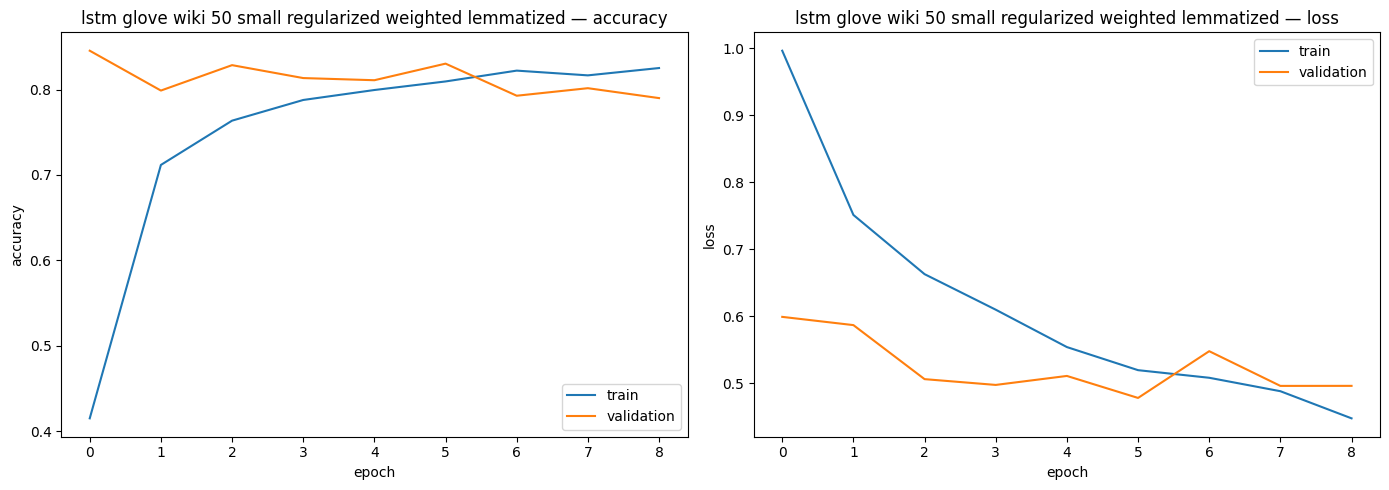

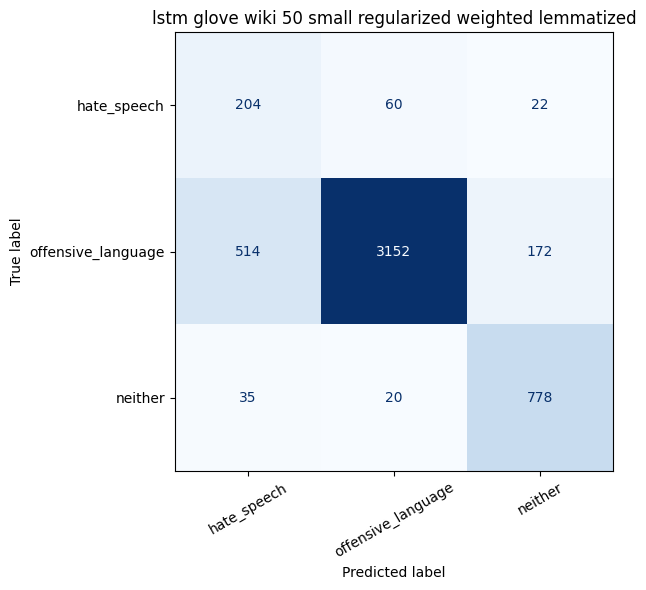

Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.5690 - loss: 0.9431 - val_accuracy: 0.8454 - val_loss: 0.5777
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7600 - loss: 0.7147 - val_accuracy: 0.8538 - val_loss: 0.4948
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.7886 - loss: 0.6238 - val_accuracy: 0.8417 - val_loss: 0.4832
Epoch 4/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.7961 - loss: 0.5682 - val_accuracy: 0.8298 - val_loss: 0.4740
Epoch 5/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8142 - loss: 0.5301 - val_accuracy: 0.8280 - val_loss: 0.4594
Epoch 6/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8122 - loss: 0.4938 - val_accuracy: 0.8263 - val_loss: 0.4539
Epoch 7/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8157 - loss: 0.4673 - val_accuracy: 0.8074 - val_loss: 0.4655
Epoch 8/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8253 - loss: 0.4491 - 

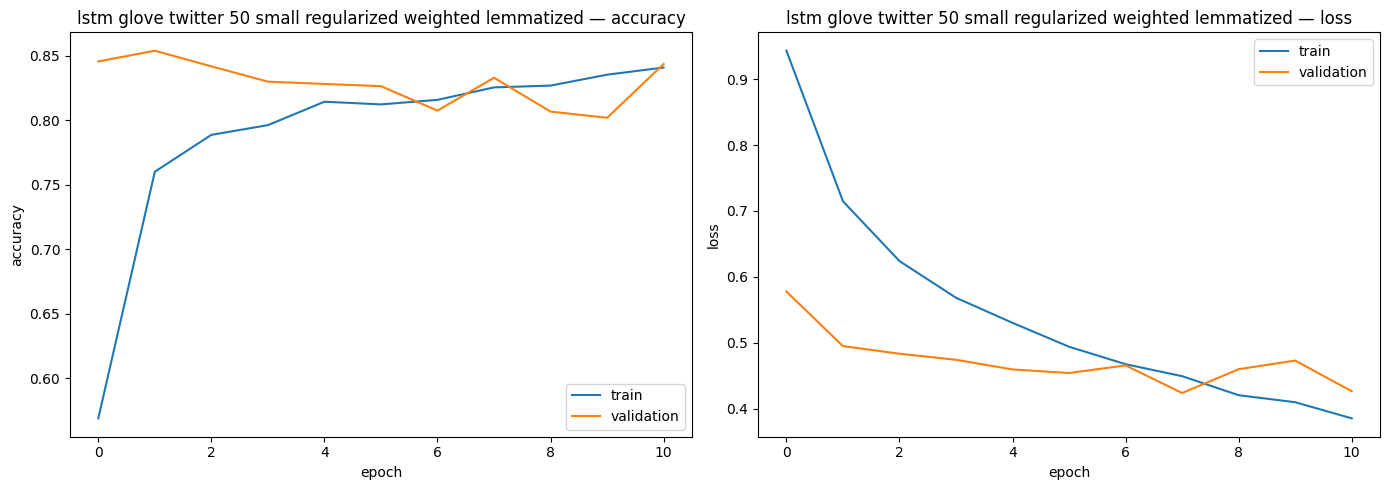

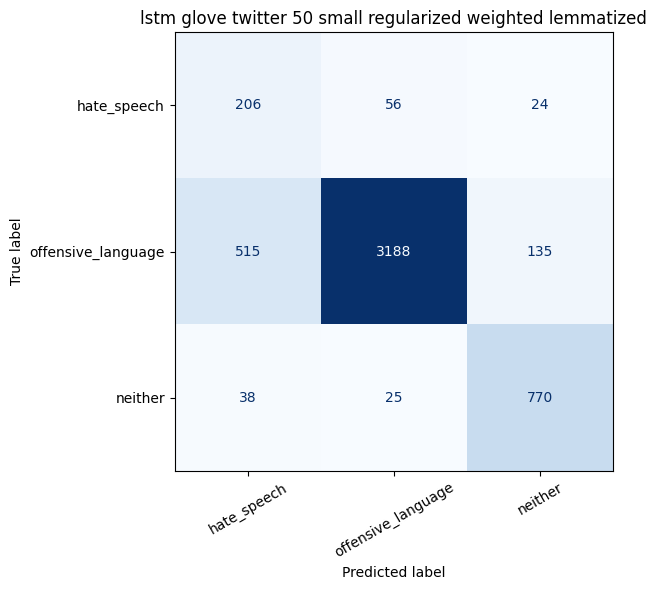

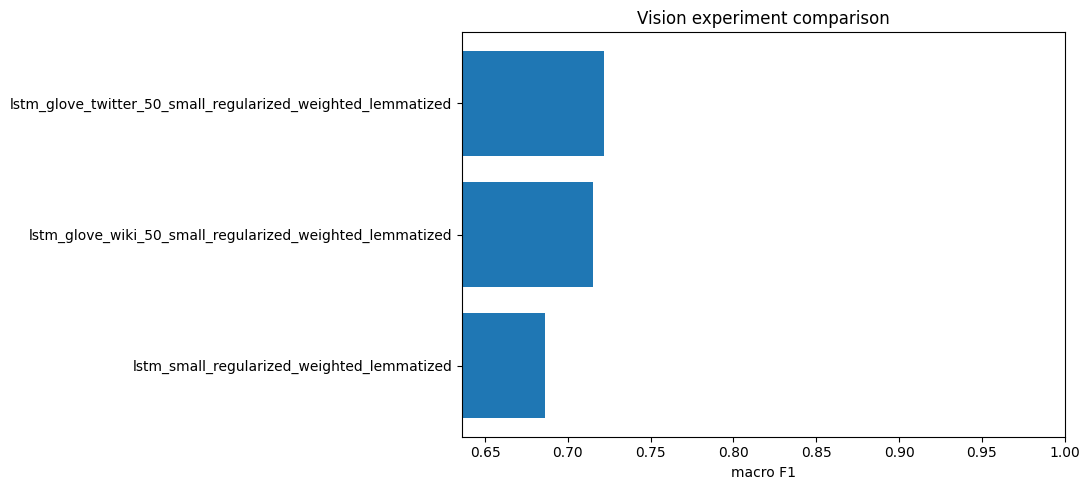

,experiment_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,misclassified_samples,epochs_trained,training_time_seconds,trainable_parameters,non_trainable_parameters
0,lstm_glove_twitter_50_small_regularized_weight...,0.840024,0.691827,0.825097,0.721803,0.864241,793,11,130.258292,1011203,0
1,lstm_glove_wiki_50_small_regularized_weighted_...,0.833972,0.682192,0.822840,0.715463,0.857891,823,9,104.720552,1011203,0
2,lstm_small_regularized_weighted_lemmatized,0.818035,0.657402,0.774256,0.686156,0.842220,902,7,86.142427,1292995,0


In [15]:
embedding_specs = [
    ("glove_wiki_50", "glove-wiki-gigaword-50", 50),
    ("glove_twitter_50", "glove-twitter-50", 50),
]

glove_experiments = []
for short_name, gensim_name, dim in embedding_specs:
    embedding_model = load_embedding(gensim_name)
    # Coverage is measured before training so missing embedding words are visible.
    matrix, coverage, missing = build_embedding_matrix(
        embedding_model=embedding_model,
        word_index=lemmatized["tokenizer"].word_index,
        vocab_size=VOCAB_SIZE,
        embedding_dim=dim,
        seed=SEED,
    )
    coverage.to_csv(NLP.tables / f"{short_name}_coverage.csv", index=False)
    missing.to_csv(NLP.tables / f"{short_name}_missing_word_examples.csv", index=False)
    display(coverage.assign(embedding=short_name))

    glove_experiments.append(NlpExperiment(
        name=f"lstm_{short_name}_small_regularized_weighted_lemmatized",
        build_model=lambda matrix=matrix: build_pretrained_small_regularized_lstm(
            matrix,
            len(TARGET_NAMES),
            trainable=True,
        ),
        class_weight=lemmatized["class_weight"],
    ))

nlp_results.update(run_many(
    glove_experiments,
    lemmatized["x_train"],
    lemmatized["y_train"],
    lemmatized["x_test"],
    lemmatized["y_test"],
    lemmatized["test_df"],
    NLP,
))

glove_table = comparison(
    nlp_results,
    [
        "lstm_small_regularized_weighted_lemmatized",
        "lstm_glove_wiki_50_small_regularized_weighted_lemmatized",
        "lstm_glove_twitter_50_small_regularized_weighted_lemmatized",
    ],
    NLP.tables / "glove_comparison.csv",
)
plot_metric_comparison(glove_table, NLP.figures / "comparisons" / "glove_macro_f1_comparison.png")
glove_table


**Takeaway**

Twitter GloVe covers more words than wiki GloVe and gives the best macro F1. That fits the dataset: tweets have slang, abbreviations, and noisy spelling that general news embeddings miss more often.


## 10. Final NLP Comparison

The final registry combines all NLP runs and ranks them by the same metric rule.


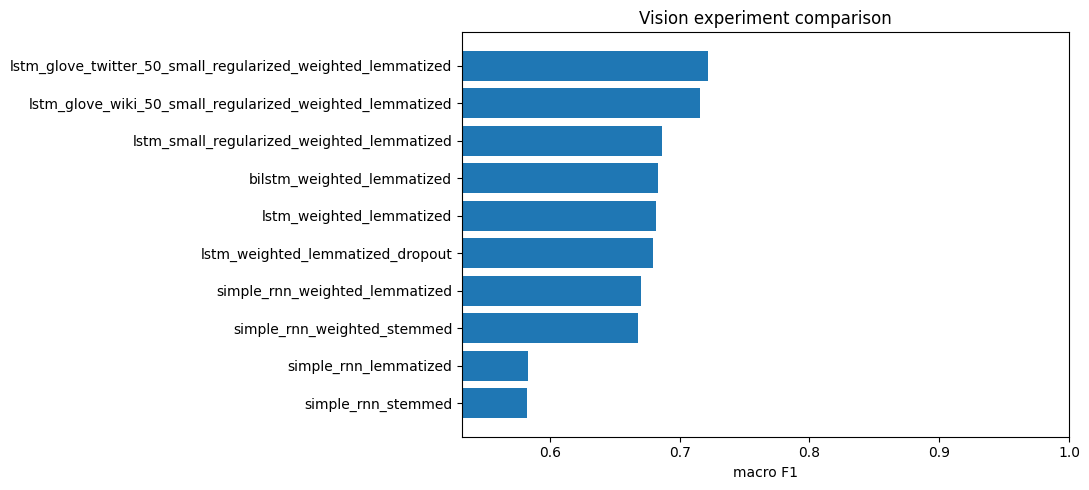

,experiment_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,misclassified_samples,epochs_trained,training_time_seconds,trainable_parameters,non_trainable_parameters
0,lstm_glove_twitter_50_small_regularized_weight...,0.840024,0.691827,0.825097,0.721803,0.864241,793,11,130.258292,1011203,0
1,lstm_glove_wiki_50_small_regularized_weighted_...,0.833972,0.682192,0.822840,0.715463,0.857891,823,9,104.720552,1011203,0
2,lstm_small_regularized_weighted_lemmatized,0.818035,0.657402,0.774256,0.686156,0.842220,902,7,86.142427,1292995,0
3,bilstm_weighted_lemmatized,0.809361,0.653809,0.783676,0.683735,0.835517,945,5,20.211881,2663043,0
4,lstm_weighted_lemmatized,0.799677,0.660434,0.785245,0.681540,0.830711,993,5,16.220682,2611587,0
5,lstm_weighted_lemmatized_dropout,0.811378,0.653608,0.764045,0.679234,0.836296,935,6,20.041328,2611587,0
6,simple_rnn_weighted_lemmatized,0.810369,0.643347,0.754042,0.670177,0.835793,940,4,25.193455,2574531,0
7,simple_rnn_weighted_stemmed,0.806536,0.650629,0.751206,0.667714,0.837786,959,4,25.672314,2574531,0
8,simple_rnn_lemmatized,0.886625,0.566972,0.599772,0.582907,0.860194,562,4,24.060275,2574531,0
9,simple_rnn_stemmed,0.887230,0.569430,0.596273,0.582466,0.860479,559,4,27.617948,2574531,0


In [16]:
final_nlp_registry = registry(nlp_results, NLP.tables / "nlp_experiment_registry.csv")
plot_metric_comparison(final_nlp_registry, NLP.figures / "comparisons" / "nlp_macro_f1_comparison.png")
final_nlp_registry


**Final Takeaway**

The selected NLP model is `lstm_glove_twitter_50_small_regularized_weighted_lemmatized`. It has the best macro F1 in the saved registry, so it is the model used by the inference notebook.
